#### **Otto Group Product Classification Challenge**

**Goal**: Multi-class classification of products into 9 categories using 93 obfuscated count features.  
**Metric**: Multi-class logarithmic loss (logloss)  
**Approach**: KNN + LightGBM ensemble with stratified k-fold CV  
**Dataset**: 61,878 train / 144,368 test rows

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FOLDS = 5
np.random.seed(RANDOM_STATE)

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nTarget distribution:")
print(train['target'].value_counts().sort_index())

Train shape: (61878, 95)
Test shape:  (144368, 94)

Target distribution:
target
Class_1     1929
Class_2    16122
Class_3     8004
Class_4     2691
Class_5     2739
Class_6    14135
Class_7     2839
Class_8     8464
Class_9     4955
Name: count, dtype: int64


#### **Exploratory Data Analysis**

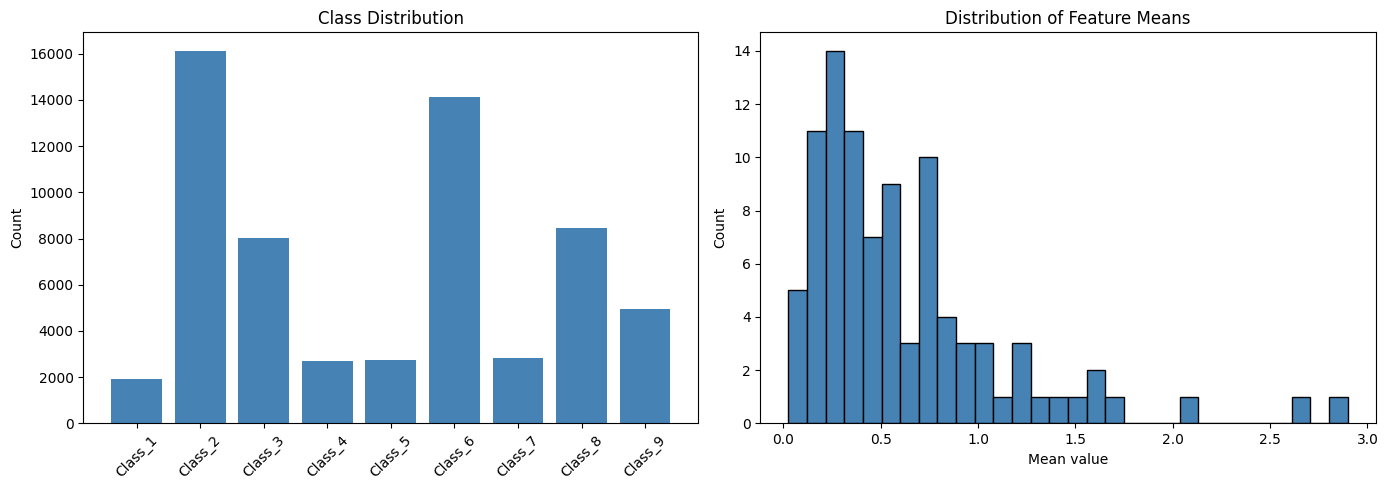


Missing values: 0
Zero-heavy features (>90% zeros): 19 / 93


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = train['target'].value_counts().sort_index()
axes[0].bar(range(len(class_counts)), class_counts.values, color='steelblue')
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=45)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Feature statistics
feat_cols = [f'feat_{i}' for i in range(1, 94)]
feature_means = train[feat_cols].mean().values
axes[1].hist(feature_means, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Feature Means')
axes[1].set_xlabel('Mean value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\nMissing values: {train[feat_cols].isnull().sum().sum()}")
print(f"Zero-heavy features (>90% zeros): {(train[feat_cols] == 0).mean().gt(0.9).sum()} / 93")

#### **Feature Engineering & Preprocessing**

In [4]:
# Separate IDs and target
train_ids = train['id']
test_ids = test['id']

# Encode target: Class_1..Class_9 -> 0..8
le = LabelEncoder()
y = le.fit_transform(train['target'])
n_classes = len(le.classes_)
print(f"Classes: {le.classes_}")
print(f"Encoded: 0..{n_classes - 1}")

# Feature matrix
feat_cols = [f'feat_{i}' for i in range(1, 94)]
X = train[feat_cols].values.astype(np.float32)
X_test = test[feat_cols].values.astype(np.float32)

print(f"\nX shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")

Classes: ['Class_1' 'Class_2' 'Class_3' 'Class_4' 'Class_5' 'Class_6' 'Class_7'
 'Class_8' 'Class_9']
Encoded: 0..8

X shape: (61878, 93)
X_test shape: (144368, 93)


In [5]:
# Additional features: log1p transform (count features benefit from log scaling)
X_log = np.log1p(X)
X_test_log = np.log1p(X_test)

# Row-level aggregates
X_row_sum = X.sum(axis=1, keepdims=True)
X_row_nonzero = (X > 0).sum(axis=1, keepdims=True).astype(np.float32)
X_row_max = X.max(axis=1, keepdims=True)

X_test_row_sum = X_test.sum(axis=1, keepdims=True)
X_test_row_nonzero = (X_test > 0).sum(axis=1, keepdims=True).astype(np.float32)
X_test_row_max = X_test.max(axis=1, keepdims=True)

# Combined feature set for LightGBM (raw + log + aggregates)
X_lgb = np.hstack([X, X_log, X_row_sum, X_row_nonzero, X_row_max])
X_test_lgb = np.hstack([X_test, X_test_log, X_test_row_sum, X_test_row_nonzero, X_test_row_max])

print(f"LightGBM feature set: {X_lgb.shape[1]} features (93 raw + 93 log + 3 aggregates)")

# Scaled features for KNN (log-transformed + standardized)
scaler = StandardScaler()
X_knn = scaler.fit_transform(X_log)
X_test_knn = scaler.transform(X_test_log)

print(f"KNN feature set: {X_knn.shape[1]} features (93 log-scaled)")

LightGBM feature set: 189 features (93 raw + 93 log + 3 aggregates)
KNN feature set: 93 features (93 log-scaled)


#### **KNN Model — Stratified K-Fold with OOF Predictions**

In [6]:
%%time

knn_params = {
    'n_neighbors': 32,
    'weights': 'distance',
    'metric': 'minkowski',
    'p': 2,
    'n_jobs': -1
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_knn = np.zeros((len(X), n_classes))
test_knn = np.zeros((len(X_test), n_classes))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_knn, y)):
    print(f"Fold {fold + 1}/{N_FOLDS}")
    
    X_tr, X_val = X_knn[train_idx], X_knn[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    knn = KNeighborsClassifier(**knn_params)
    knn.fit(X_tr, y_tr)
    
    oof_knn[val_idx] = knn.predict_proba(X_val)
    test_knn += knn.predict_proba(X_test_knn) / N_FOLDS
    
    fold_logloss = log_loss(y_val, oof_knn[val_idx])
    print(f"  Fold logloss: {fold_logloss:.5f}")

knn_oof_logloss = log_loss(y, oof_knn)
knn_oof_f1 = f1_score(y, oof_knn.argmax(axis=1), average='macro')
print(f"\nKNN OOF logloss: {knn_oof_logloss:.5f}")
print(f"KNN OOF Macro F1: {knn_oof_f1:.5f}")

Fold 1/5
  Fold logloss: 0.80973
Fold 2/5
  Fold logloss: 0.85711
Fold 3/5
  Fold logloss: 0.87439
Fold 4/5
  Fold logloss: 0.81426
Fold 5/5
  Fold logloss: 0.81361

KNN OOF logloss: 0.83382
KNN OOF Macro F1: 0.69960
CPU times: user 7min 57s, sys: 271 ms, total: 7min 58s
Wall time: 50.5 s


#### **LightGBM Model — Stratified K-Fold with OOF Predictions**

In [7]:
%%time

lgb_params = {
    'objective': 'multiclass',
    'num_class': n_classes,
    'metric': 'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 7,
    'min_child_samples': 20,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 1.0,
    'verbose': -1,
    'seed': RANDOM_STATE,
    'n_jobs': -1
}

NUM_BOOST_ROUND = 3000
EARLY_STOPPING = 100

oof_lgb = np.zeros((len(X), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
lgb_best_iters = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_lgb, y)):
    print(f"Fold {fold + 1}/{N_FOLDS}")
    
    X_tr, X_val = X_lgb[train_idx], X_lgb[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    
    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING),
            lgb.log_evaluation(200)
        ]
    )
    
    lgb_best_iters.append(model.best_iteration)
    oof_lgb[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_lgb += model.predict(X_test_lgb, num_iteration=model.best_iteration) / N_FOLDS
    
    fold_logloss = log_loss(y_val, oof_lgb[val_idx])
    print(f"  Fold logloss: {fold_logloss:.5f} (best iter: {model.best_iteration})\n")

lgb_oof_logloss = log_loss(y, oof_lgb)
lgb_oof_f1 = f1_score(y, oof_lgb.argmax(axis=1), average='macro')
print(f"\nLightGBM OOF logloss: {lgb_oof_logloss:.5f}")
print(f"LightGBM OOF Macro F1: {lgb_oof_f1:.5f}")
print(f"Best iterations: {lgb_best_iters} (mean: {np.mean(lgb_best_iters):.0f})")

Fold 1/5
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.487202
[400]	valid_0's multi_logloss: 0.465968
Early stopping, best iteration is:
[416]	valid_0's multi_logloss: 0.465506
  Fold logloss: 0.46551 (best iter: 416)

Fold 2/5
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.49247
[400]	valid_0's multi_logloss: 0.474253
Early stopping, best iteration is:
[420]	valid_0's multi_logloss: 0.47337
  Fold logloss: 0.47337 (best iter: 420)

Fold 3/5
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.474611
[400]	valid_0's multi_logloss: 0.45387
Early stopping, best iteration is:
[461]	valid_0's multi_logloss: 0.452904
  Fold logloss: 0.45290 (best iter: 461)

Fold 4/5
Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.480873
[400]	valid_0's multi_logloss: 0.458676
Early stopping, best iteration is:
[480]	valid_0

#### **Find Feature Importance of the  (LightGBM)**

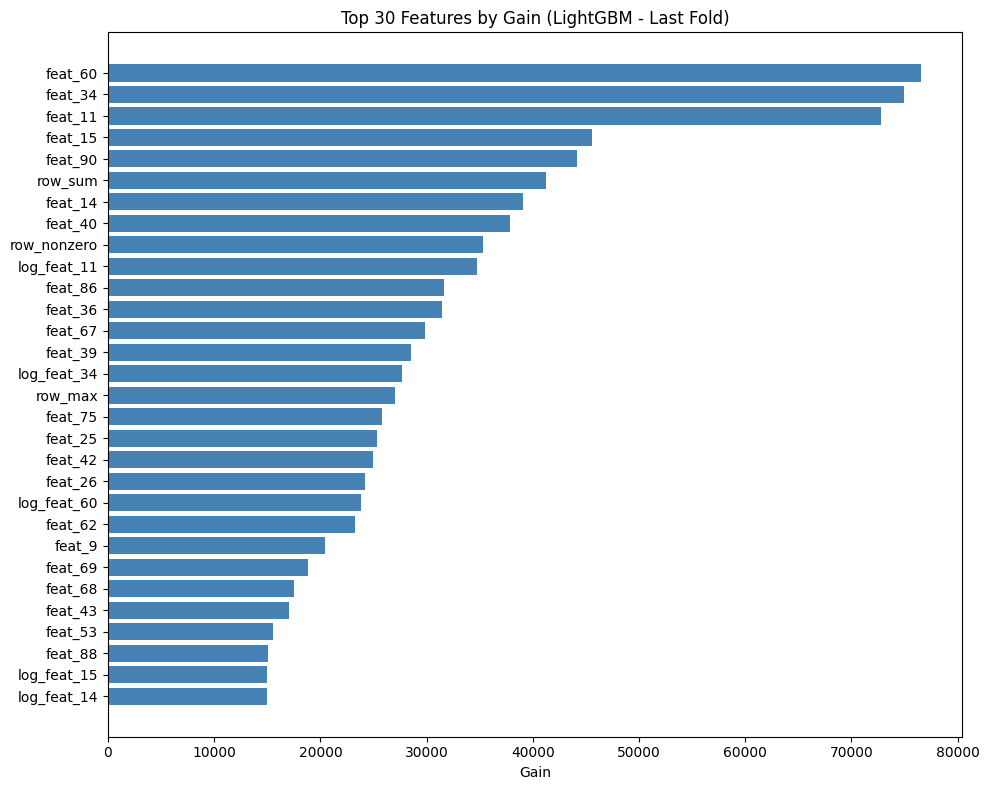

In [8]:
# Plot top 30 features from last fold model
importance = model.feature_importance(importance_type='gain')
feat_names = [f'feat_{i}' for i in range(1, 94)] + \
             [f'log_feat_{i}' for i in range(1, 94)] + \
             ['row_sum', 'row_nonzero', 'row_max']

imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(imp_df)), imp_df['importance'].values, color='steelblue')
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'].values)
ax.invert_yaxis()
ax.set_title('Top 30 Features by Gain (LightGBM - Last Fold)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

#### **Ensemble — KNN + LightGBM**

In [9]:
from scipy.optimize import minimize

# Grid search over ensemble weights
print("=" * 60)
print("Ensemble Weight Search")
print("=" * 60)

best_logloss = np.inf
best_w = 0.0

for w_lgb in np.arange(0.0, 1.01, 0.05):
    w_knn = 1.0 - w_lgb
    oof_blend = w_lgb * oof_lgb + w_knn * oof_knn
    ll = log_loss(y, oof_blend)
    if ll < best_logloss:
        best_logloss = ll
        best_w = w_lgb

print(f"\nBest weights: LightGBM={best_w:.2f}, KNN={1 - best_w:.2f}")
print(f"Best ensemble OOF logloss: {best_logloss:.5f}")

# Also try Nelder-Mead for finer optimization
def neg_ensemble_logloss(w):
    w_lgb = w[0]
    w_lgb = np.clip(w_lgb, 0, 1)
    blend = w_lgb * oof_lgb + (1 - w_lgb) * oof_knn
    return log_loss(y, blend)

result = minimize(neg_ensemble_logloss, x0=[best_w], method='Nelder-Mead',
                  options={'xatol': 1e-5, 'fatol': 1e-7})
opt_w = np.clip(result.x[0], 0, 1)
opt_logloss = result.fun

print(f"\nOptimized weights: LightGBM={opt_w:.4f}, KNN={1 - opt_w:.4f}")
print(f"Optimized ensemble OOF logloss: {opt_logloss:.5f}")

Ensemble Weight Search

Best weights: LightGBM=0.90, KNN=0.10
Best ensemble OOF logloss: 0.45731

Optimized weights: LightGBM=0.8857, KNN=0.1143
Optimized ensemble OOF logloss: 0.45726


In [10]:
# Summary table
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

oof_ensemble = opt_w * oof_lgb + (1 - opt_w) * oof_knn
ens_f1 = f1_score(y, oof_ensemble.argmax(axis=1), average='macro')

results_table = pd.DataFrame({
    'Model': ['KNN', 'LightGBM', f'Ensemble (LGB={opt_w:.3f})'],
    'OOF Logloss': [knn_oof_logloss, lgb_oof_logloss, opt_logloss],
    'OOF Macro F1': [knn_oof_f1, lgb_oof_f1, ens_f1]
})
print(results_table.to_string(index=False))

# Pick best method
methods = {
    'KNN': (knn_oof_logloss, knn_oof_f1, test_knn),
    'LightGBM': (lgb_oof_logloss, lgb_oof_f1, test_lgb),
    'Ensemble': (opt_logloss, ens_f1, opt_w * test_lgb + (1 - opt_w) * test_knn)
}

# Best by logloss (lower is better)
best_method = min(methods, key=lambda k: methods[k][0])
best_logloss_val = methods[best_method][0]
best_f1_val = methods[best_method][1]
best_test_preds = methods[best_method][2]

print(f"\nBest model: {best_method} (OOF logloss: {best_logloss_val:.5f})")


MODEL COMPARISON
               Model  OOF Logloss  OOF Macro F1
                 KNN     0.833822      0.699600
            LightGBM     0.463109      0.787882
Ensemble (LGB=0.886)     0.457257      0.787382

Best model: Ensemble (OOF logloss: 0.45726)


In [11]:
# Classification report for best model
print(f"Classification Report — {best_method} (OOF)")
print("=" * 60)
oof_best = opt_w * oof_lgb + (1 - opt_w) * oof_knn if best_method == 'Ensemble' else (
    oof_lgb if best_method == 'LightGBM' else oof_knn
)
print(classification_report(y, oof_best.argmax(axis=1), target_names=le.classes_))

Classification Report — Ensemble (OOF)
              precision    recall  f1-score   support

     Class_1       0.75      0.55      0.63      1929
     Class_2       0.74      0.86      0.80     16122
     Class_3       0.63      0.53      0.58      8004
     Class_4       0.79      0.52      0.63      2691
     Class_5       0.98      0.97      0.98      2739
     Class_6       0.95      0.95      0.95     14135
     Class_7       0.75      0.70      0.72      2839
     Class_8       0.91      0.93      0.92      8464
     Class_9       0.87      0.89      0.88      4955

    accuracy                           0.82     61878
   macro avg       0.82      0.77      0.79     61878
weighted avg       0.82      0.82      0.82     61878



#### **Create Submission File for Kaggle**

In [ ]:
# Create submission file
submission = pd.DataFrame({'id': test_ids})
for i, cls in enumerate(le.classes_):
    submission[cls] = best_test_preds[:, i]

ts = datetime.now().strftime("%Y%m%d%H%M%S")
sub_name = './results/submission' + ts + '.csv'
submission = submission.reset_index(drop=True)
submission.to_csv(sub_name, index=False)

print(f"Best model: {best_method}")
print(f"  OOF Logloss (competition metric): {best_logloss_val:.5f}")
print(f"  OOF Macro F1: {best_f1_val:.5f}")

# Display first few rows
print("\nSubmission file preview:")
print(submission.head(10))
print('submission file:', sub_name)

In [13]:
# Sanity check: probabilities sum to ~1 per row
prob_cols = [c for c in submission.columns if c.startswith('Class_')]
row_sums = submission[prob_cols].sum(axis=1)
print(f"Row probability sums — min: {row_sums.min():.6f}, max: {row_sums.max():.6f}, mean: {row_sums.mean():.6f}")
print(f"Submission shape: {submission.shape}")
print(f"\nPredicted class distribution (argmax):")
pred_classes = submission[prob_cols].values.argmax(axis=1)
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: {(pred_classes == i).sum()}")

Row probability sums — min: 1.000000, max: 1.000000, mean: 1.000000
Submission shape: (144368, 10)

Predicted class distribution (argmax):
  Class_1: 3217
  Class_2: 43406
  Class_3: 15729
  Class_4: 4110
  Class_5: 6352
  Class_6: 33003
  Class_7: 6280
  Class_8: 20388
  Class_9: 11883
